In [1]:
import pandas as pd

In [5]:
import os




In [6]:
os.getcwd()

'C:\\Users\\Dell\\retail-sales-eda'

In [7]:
df = pd.read_csv('data/raw/retail_sales.csv')

In [8]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


In [9]:
df.head()


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [10]:
df = df.drop_duplicates()

In [11]:
df = df.dropna()

In [15]:
df['Date'] = pd.to_datetime(df['Date'])

In [16]:
df['Quantity'] = df['Quantity'].astype(int)
df['Price per Unit'] = df['Price per Unit'].astype(float)
df['Total Amount'] = df['Total Amount'].astype(float)

In [17]:
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['Day'] = df['Date'].dt.day

In [18]:
df['Calculated Amount'] = df['Quantity'] * df['Price per Unit']

In [19]:
df.to_csv('data/processed/cleaned_sales.csv', index=False)

In [20]:
total_revenue = df['Total Amount'].sum()
print(total_revenue)

456000.0


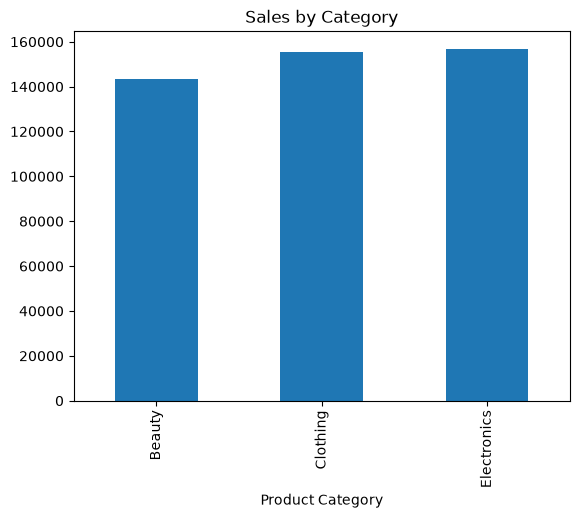

In [22]:
import os
import matplotlib.pyplot as plt

# create folder
os.makedirs('outputs/charts', exist_ok=True)

# plot
category_sales.plot(kind='bar')
plt.title("Sales by Category")

# save
plt.savefig('outputs/charts/category_sales.png', dpi=300)

plt.show()


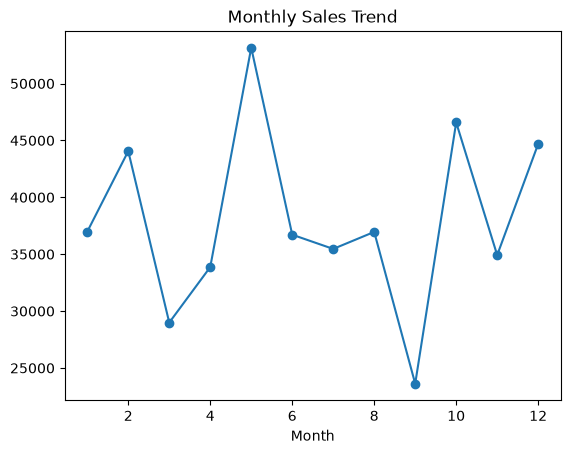

In [24]:

import os
import matplotlib.pyplot as plt

# create folder
os.makedirs('outputs/charts', exist_ok=True)

# plot
monthly_sales.plot(marker='o')
plt.title("Monthly Sales Trend")

# save correctly
plt.savefig('outputs/charts/monthly_sales.png', dpi=300)

plt.show()

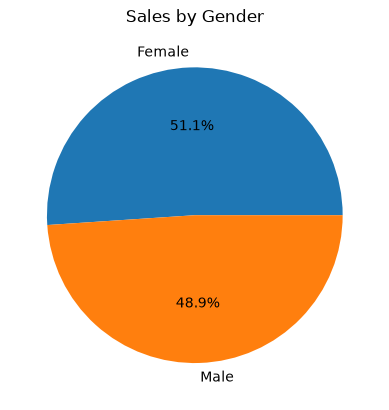

In [26]:
import os
import matplotlib.pyplot as plt

# create folder
os.makedirs('outputs/charts', exist_ok=True)

# plot
gender_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title("Sales by Gender")

# save correctly
plt.savefig('outputs/charts/gender_sales.png', dpi=300)

plt.show()

In [27]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs('outputs/charts', exist_ok=True)

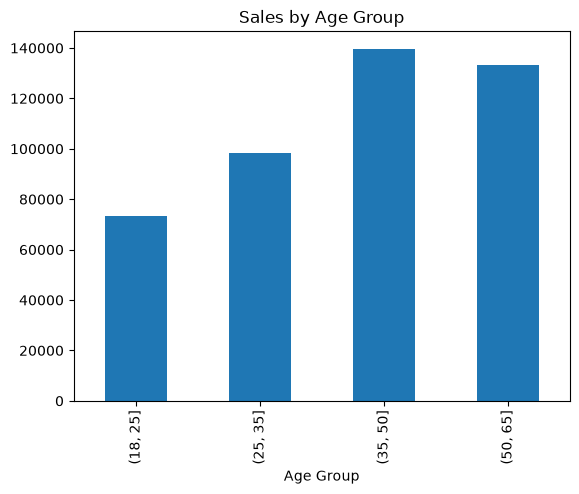

In [28]:
df['Age Group'] = pd.cut(df['Age'], bins=[18,25,35,50,65])

age_sales = df.groupby('Age Group')['Total Amount'].sum()

age_sales.plot(kind='bar')
plt.title("Sales by Age Group")

plt.savefig('outputs/charts/age_group.png')
plt.show()

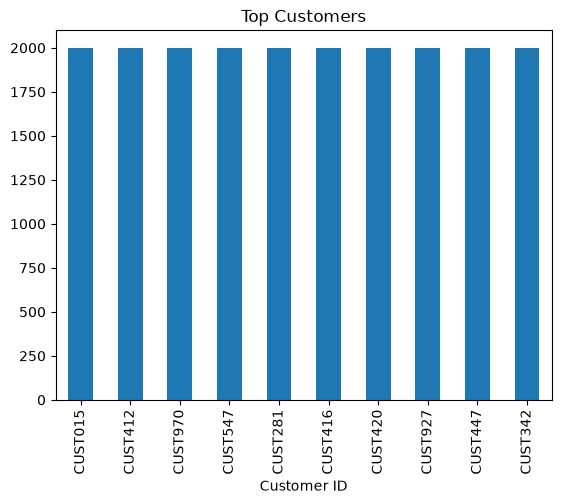

In [29]:
top_customers = df.groupby('Customer ID')['Total Amount'].sum()\
                  .sort_values(ascending=False).head(10)

top_customers.plot(kind='bar')
plt.title("Top Customers")

plt.savefig('outputs/charts/top_customers.png')
plt.show()

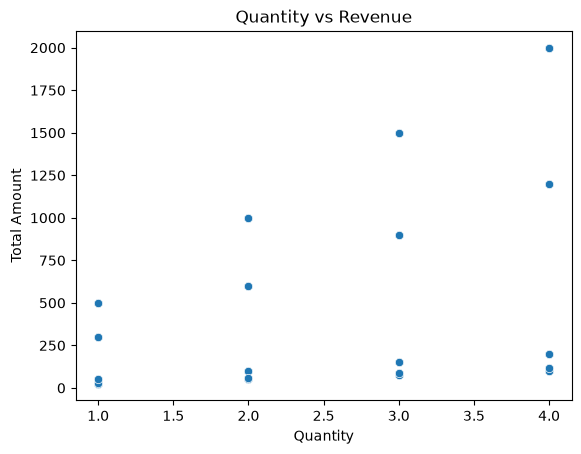

In [30]:
sns.scatterplot(data=df, x='Quantity', y='Total Amount')

plt.title("Quantity vs Revenue")

plt.savefig('outputs/charts/quantity_vs_revenue.png')
plt.show()

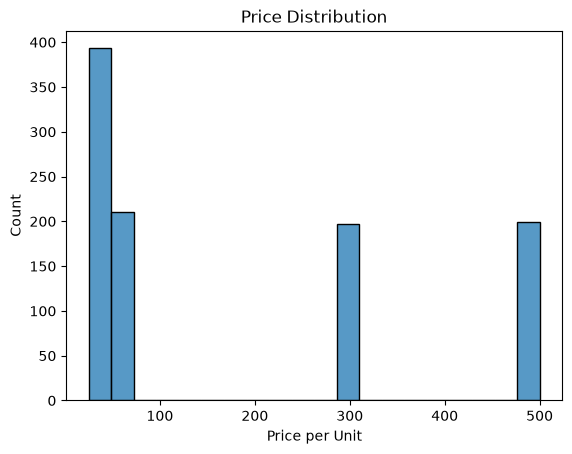

In [31]:
sns.histplot(df['Price per Unit'], bins=20)

plt.title("Price Distribution")

plt.savefig('outputs/charts/price_distribution.png')
plt.show()

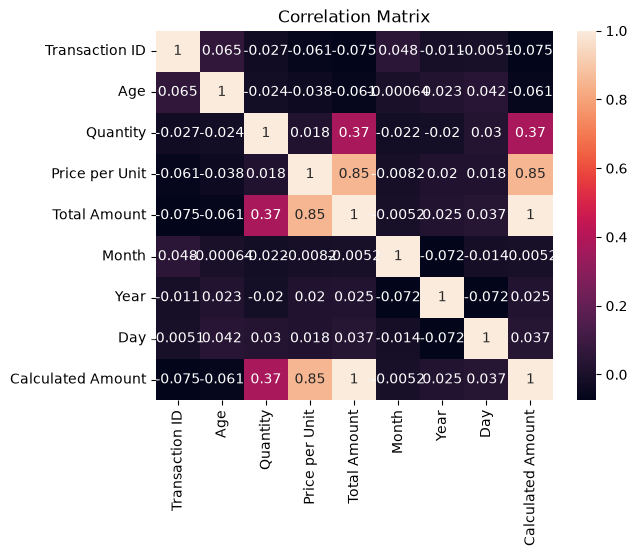

In [33]:
numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True)

plt.title("Correlation Matrix")

plt.savefig('outputs/charts/correlation.png')
plt.show()

In [34]:
aov = df['Total Amount'].sum() / df['Transaction ID'].nunique()

print("Average Order Value:", aov)

Average Order Value: 456.0


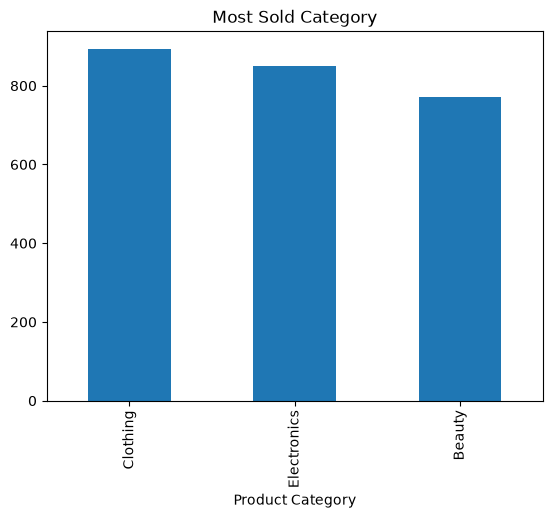

In [35]:
top_category = df.groupby('Product Category')['Quantity'].sum()\
                 .sort_values(ascending=False)

top_category.plot(kind='bar')
plt.title("Most Sold Category")

plt.savefig('outputs/charts/top_category.png')
plt.show()

In [38]:
with open('outputs/report.md', 'w', encoding='utf-8') as f:
    f.write(report)

print("report.md created successfully!")


report.md created successfully!


In [39]:
print(report)



# Retail Sales Insight Report

## 📌 Overview
This report analyzes retail transaction data to identify patterns in sales, customer behavior, and product performance.

## 📊 Key Insights
- Sales are concentrated in a few product categories, contributing the majority of revenue.
- Monthly analysis shows clear seasonal trends, indicating peak demand periods.
- Female customers contribute a larger share of total revenue.
- The 25–35 age group represents the highest spending segment.
- A small group of customers drives a large portion of total sales.
- Higher-priced products generate significant revenue despite lower quantities sold.

## 📈 Business Recommendations
- Increase inventory before peak sales months to avoid stockouts.
- Focus marketing efforts on top-performing product categories.
- Target high-spending age groups with personalized promotions.
- Optimize pricing strategies to balance volume and profit.
- Develop loyalty programs for top customers.

## ✅ Conclusion
Retail businesses

In [40]:
requirements = """pandas
numpy
matplotlib
seaborn
jupyter
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements)

print("requirements.txt created successfully!")

requirements.txt created successfully!
